In [1]:
print("python is working")

python is working


In [2]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [3]:
%pip install pandas openpyxl

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
   - -------------------------------------- 0.3/9.9 MB 2.9 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.9 MB 3.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/9.9 MB 3.8 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/9.9 MB 4.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/9.9 MB 4.1 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/9.9 MB 4.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 4.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.0/9.9 MB 4.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.3/9.9 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.7/9.9 MB 4.8 MB/s eta 0:00:02
   ----------- ----


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\shiri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

print("Pandas is working")

Pandas is working


In [5]:
file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()
clean_df.shape

(536641, 8)

In [12]:
clean_df = clean_df.dropna(subset=["Description"])

clean_df.shape

(535187, 8)

In [13]:
clean_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

clean_df.shape

(524878, 8)

In [14]:
clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
clean_df[
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "Revenue"]
].head()

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


In [16]:
clean_df.to_csv(
    "../data/processed/cleaned_online_retail.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [17]:
total_revenue = clean_df["Revenue"].sum()
total_orders = clean_df["InvoiceNo"].nunique()
total_products_sold = clean_df["Quantity"].sum()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Products Sold:", total_products_sold)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 10642110.8
Total Orders: 19960
Total Products Sold: 5572420
Average Order Value: 533.17


In [18]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    clean_df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

monthly_revenue

,Month,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [21]:
%pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------------------------------- 80.3/80.3 kB 897.7 kB/s eta 0:00:00
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB 6.9 MB/s eta 0:00:02
   --- ------------------------------------ 0.7/9.3 MB 7.5 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.3 MB 7.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.5/9.3 MB 7.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.3 MB 7.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.3 MB 7.4 MB/s eta 0:00:01
   ---------- ----------------------------- 2.5/9.3 MB 7.5 MB/s eta 0:00:01
   ------------ -----


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\shiri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


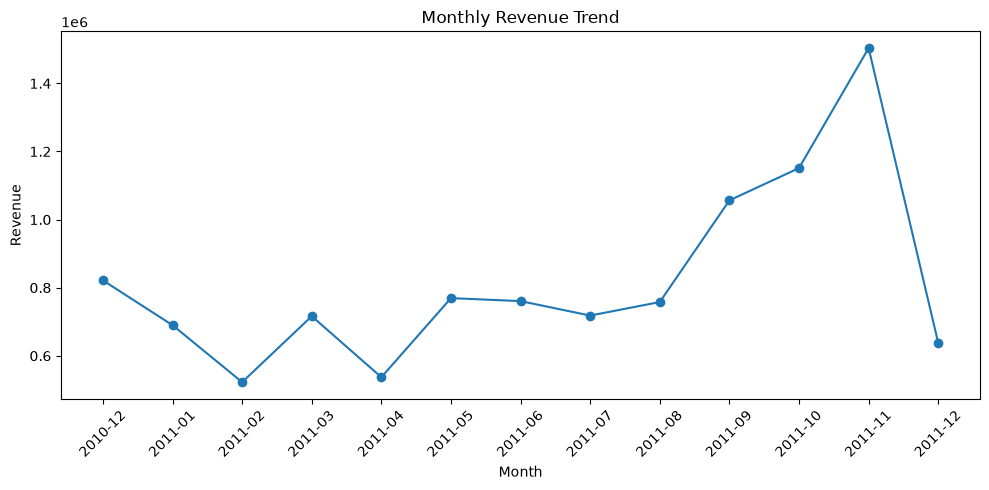

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

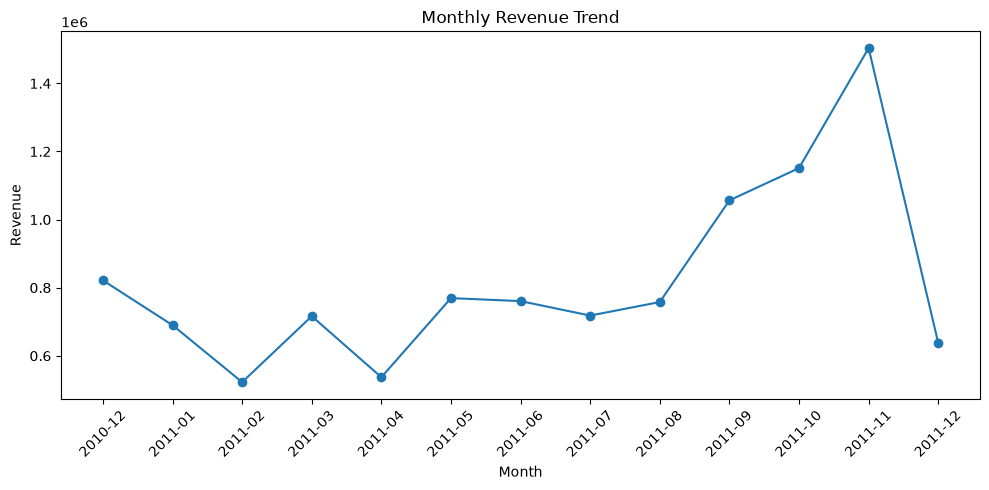

Monthly revenue chart saved successfully


In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Monthly revenue chart saved successfully")

In [24]:
top_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


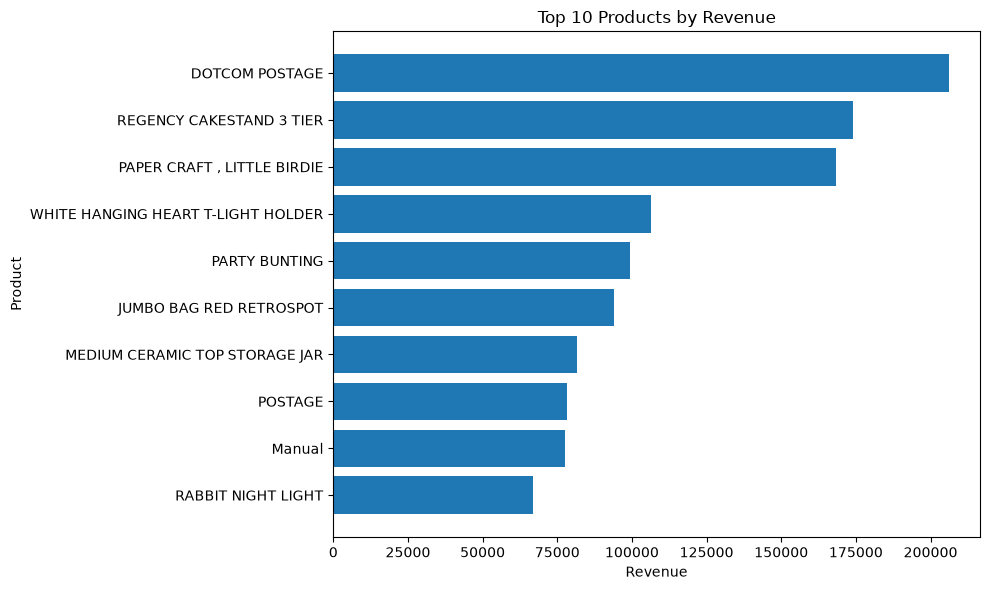

Top products chart saved successfully


In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../images/top_10_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top products chart saved successfully")

In [26]:
top_countries = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_countries

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


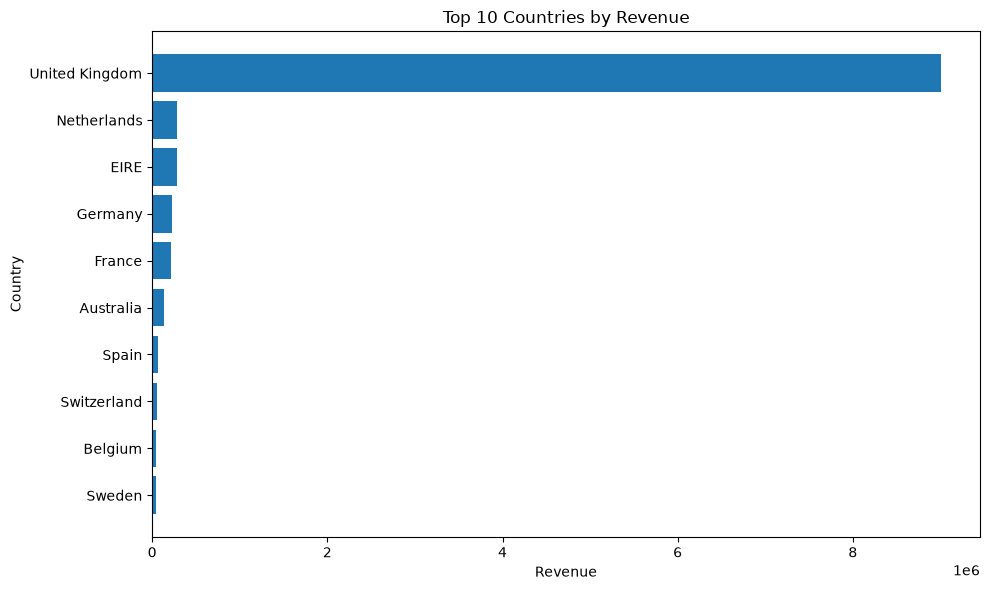

Top countries chart saved successfully


In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../images/top_10_countries_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top countries chart saved successfully")

In [28]:
top_customers = (
    clean_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


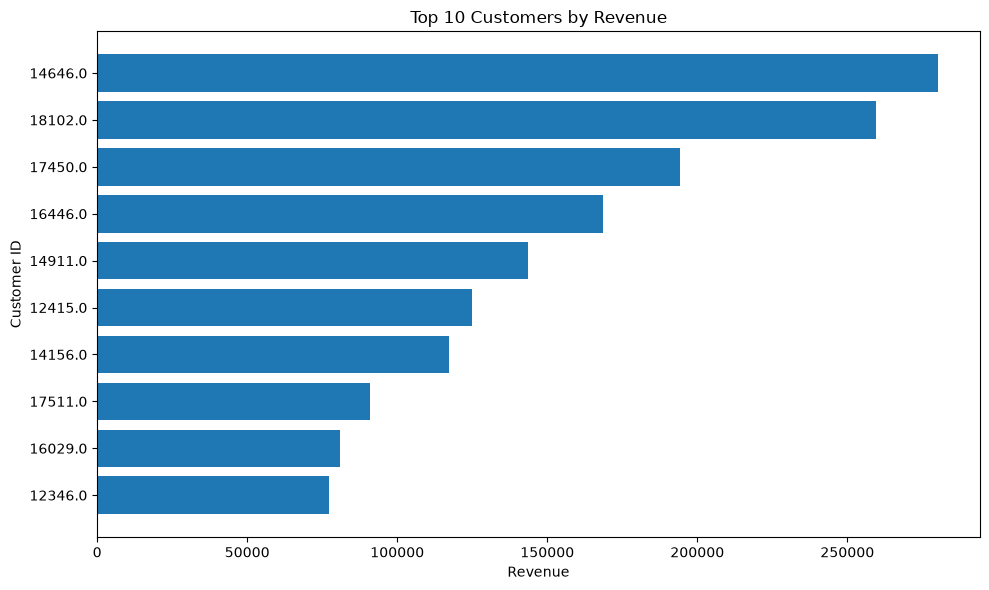

Top customers chart saved successfully


In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["CustomerID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../images/top_10_customers_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top customers chart saved successfully")

In [30]:
cancelled_orders = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled_order_count = cancelled_orders["InvoiceNo"].nunique()
total_original_orders = df["InvoiceNo"].nunique()

cancellation_rate = (
    cancelled_order_count / total_original_orders
) * 100

print("Cancelled Orders:", cancelled_order_count)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Cancelled Orders: 3836
Cancellation Rate: 14.81 %


In [31]:
cancelled_orders[
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "Country"]
].head()

,InvoiceNo,Description,Quantity,UnitPrice,Country
141,C536379,Discount,-1,27.50,United Kingdom
154,C536383,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,United Kingdom
235,C536391,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,United Kingdom
236,C536391,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,United Kingdom
237,C536391,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,United Kingdom


In [32]:
order_status = pd.DataFrame({
    "Status": ["Completed Orders", "Cancelled Orders"],
    "Count": [
        total_orders,
        cancelled_order_count
    ]
})

order_status

,Status,Count
0,Completed Orders,19960
1,Cancelled Orders,3836


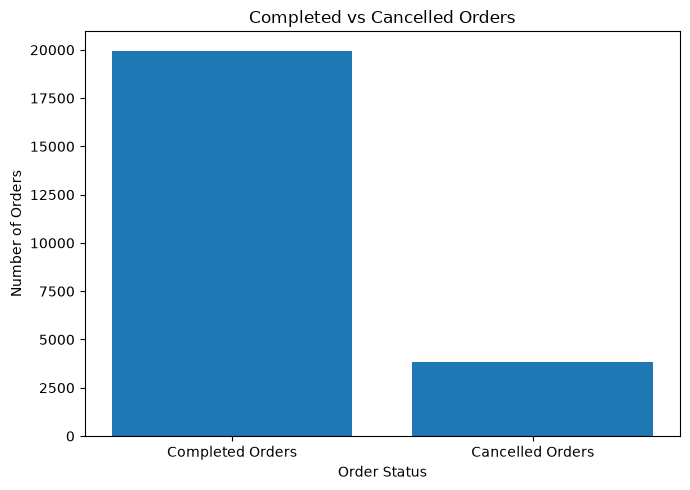

Cancellation chart saved successfully


In [33]:
plt.figure(figsize=(7, 5))

plt.bar(
    order_status["Status"],
    order_status["Count"]
)

plt.title("Completed vs Cancelled Orders")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig(
    "../images/completed_vs_cancelled_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cancellation chart saved successfully")

In [34]:
best_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

best_product = top_products.iloc[0]
best_country = top_countries.iloc[0]
best_customer = top_customers.iloc[0]

print("BUSINESS INSIGHTS")
print("-----------------")
print(
    "Highest revenue month:",
    best_month["Month"],
    "- Revenue:",
    round(best_month["Revenue"], 2)
)

print(
    "Top product:",
    best_product["Description"],
    "- Revenue:",
    round(best_product["Revenue"], 2)
)

print(
    "Top country:",
    best_country["Country"],
    "- Revenue:",
    round(best_country["Revenue"], 2)
)

print(
    "Top customer ID:",
    int(best_customer["CustomerID"]),
    "- Revenue:",
    round(best_customer["Revenue"], 2)
)

print(
    "Cancellation rate:",
    round(cancellation_rate, 2),
    "%"
)

BUSINESS INSIGHTS
-----------------
Highest revenue month: 2011-11 - Revenue: 1503866.78
Top product: DOTCOM POSTAGE - Revenue: 206248.77
Top country: United Kingdom - Revenue: 9001744.09
Top customer ID: 14646 - Revenue: 280206.02
Cancellation rate: 14.81 %
